# Crohn's Disease Microbiome — Exploratory Data Analysis

**Project:** crohns-microbiome-ml  
**Dataset:** HMP2 / iHMP (Human Microbiome Project 2 — IBD cohort)  
**Goal:** Explore the OTU abundance table and metadata to understand the dataset before modeling.


In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import skbio as skbio
import scipy as scipy
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 
import umap 
import umap.plot

print('Libraries loaded successfully!')

Libraries loaded successfully!


In [79]:
metadata = pd.read_csv('/Users/liamcampbell/Desktop/crohns-microbiome-ml/data/hmp2_metadata_2018-08-20.csv', low_memory=False)
otuTable = pd.read_csv('/Users/liamcampbell/Desktop/crohns-microbiome-ml/data/taxonomic_profiles.tsv.gz', sep= '\t', index_col=0)


print(metadata.shape, otuTable.shape)

meta_16S = metadata[metadata['data_type'].str.contains('16S', na=False)]
print(meta_16S['diagnosis'].value_counts())

print('CD = Crohns Disease')
print('UC = Ulcerative Colitis')
print('nonIBD = Healthy Controls')


(5533, 490) (982, 179)
diagnosis
CD        211
UC         89
nonIBD     58
Name: count, dtype: int64
CD = Crohns Disease
UC = Ulcerative Colitis
nonIBD = Healthy Controls


In [80]:
# Join OTU table with diagnosis labels
# OTU table: rows=taxa, cols=samples — transpose so rows=samples
otu_t = otuTable.T  # now (179, 982)
otu_t.index.name = 'External ID'

# Join on External ID
meta_16s = metadata[metadata['data_type'].str.contains('16S', na=False)]
otu_meta = otu_t.join(meta_16s.set_index('External ID')[['diagnosis', 'week_num', 'Participant ID']], how='inner')

print("Joined shape:", otu_meta.shape)
print(otu_meta['diagnosis'].value_counts())

Joined shape: (178, 985)
diagnosis
CD        86
nonIBD    46
UC        46
Name: count, dtype: int64


In [81]:
# Q1: Samples per group
print("Total samples:", len(otu_meta))
print(otu_meta['diagnosis'].value_counts())

# Q2: Number of bacterial taxa
n_taxa = otuTable.shape[0]
print("\nNumber of taxa:", n_taxa)

# Q3: Sparsity (% zeros)
otu_only = otu_meta.iloc[:, :982]  # just the OTU columns
sparsity = (otu_only == 0).sum().sum() / otu_only.size * 100
print(f"\nSparsity: {sparsity:.1f}% zeros")

# Q4: Top 10 most abundant taxa
top10 = otu_only.sum().sort_values(ascending=False).head(10)
print("\nTop 10 taxa:\n", top10)

# Q5: Samples with very few reads (potential quality issues)
read_counts = otu_only.sum(axis=1)
print("\nRead counts per sample:")
print(read_counts.describe())
low_quality = read_counts[read_counts < read_counts.quantile(0.05)]
print(f"\nPotential low-quality samples (<5th percentile): {len(low_quality)}")

Total samples: 178
diagnosis
CD        86
nonIBD    46
UC        46
Name: count, dtype: int64

Number of taxa: 982

Sparsity: 91.7% zeros

Top 10 taxa:
 Unc05bd1    436194.0
Unc64172    409198.0
Unc054vi    294448.0
Unc91005    111388.0
UncG3786    109438.0
UncO8895     75291.0
Unc01pk4     47133.0
Unc00y95     46903.0
UncC1868     44063.0
Unc69508     41982.0
dtype: object

Read counts per sample:
count       178.0
unique      178.0
top       23607.0
freq          1.0
dtype: float64

Potential low-quality samples (<5th percentile): 9


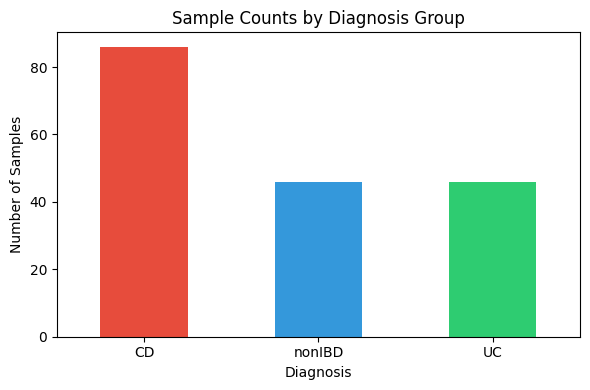

In [82]:
# Bar chart of sample counts by diagnosis
fig, ax = plt.subplots(figsize=(6, 4))
otu_meta['diagnosis'].value_counts().plot(kind='bar', ax=ax, color=['#e74c3c','#3498db','#2ecc71'])
ax.set_title('Sample Counts by Diagnosis Group')
ax.set_xlabel('Diagnosis')
ax.set_ylabel('Number of Samples')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('../figures/sample_counts_by_diagnosis.png', dpi=150)
plt.show()

Now that we have our general OTU table, we must filter it to only include **Prevalent** data. This is because most of our data is near-zero. By doing this, we remove the near-zero data and remove the noise associated with it. 
- *Prevalence* - the fraction of samples where a taxon has count > 0. 

In [83]:
prevalence = (otu_only > 0).mean(axis=0)
prevalent_taxa = prevalence[prevalence > 0.1].index
otu_prevalent = otu_only[prevalent_taxa]
print(f"\nNumber of prevalent taxa (>10% samples): {otu_prevalent.shape[1]}")


Number of prevalent taxa (>10% samples): 184


In [84]:
# CLR on prevalent taxa
pseudo = otu_prevalent.astype(float) + 0.5
log_vals = np.log(pseudo)
otu_clr = log_vals.subtract(log_vals.mean(axis=1), axis=0)

print(f"CLR shape: {otu_clr.shape}")
print(f"Value range: [{otu_clr.values.min():.2f}, {otu_clr.values.max():.2f}]")
print(f"Row means (should all be ~0): {otu_clr.mean(axis=1).head(3).values.round(6)}")

CLR shape: (178, 184)
Value range: [-2.77, 10.23]
Row means (should all be ~0): [-0.  0.  0.]


Now that we have removed low-prevalence features and applied our Centered-Log Ratio transformation to the data set, we will remove features with near-zero variance. 

Features before filtering: 184
Features after filtering: 179 (kept 179 features present in ≥5% of samples)
Feature presence histogram saved to figures/feature_presence_histogram.png


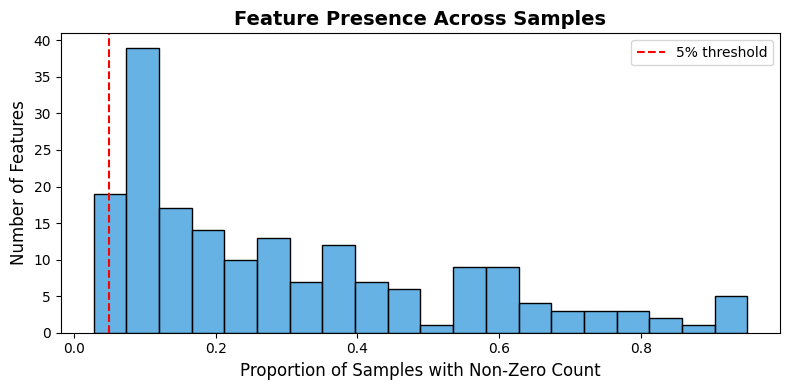

In [85]:
#Remove features with near-zero variance (e.g., present in <5% of samples) to reduce noise and computational load.
presence = (otu_clr > 0).sum() / len(otu_clr)
features_to_keep = presence[presence >= 0.05].index
otu_clr_filtered = otu_clr[features_to_keep] #our matrix after filtering out rare taxa
print(f"Features before filtering: {otu_clr.shape[1]}")
print(f"Features after filtering: {otu_clr_filtered.shape[1]} (kept {len(features_to_keep)} features present in ≥5% of samples)")   
plt.figure(figsize=(8, 4))
sns.histplot(presence, bins=20, kde=False, color='#3498db')
plt.axvline(0.05, color='red', linestyle='--', label='5% threshold')
plt.title('Feature Presence Across Samples', fontsize=14, fontweight='bold')
plt.xlabel('Proportion of Samples with Non-Zero Count', fontsize=12)
plt.ylabel('Number of Features', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('../figures/feature_presence_histogram.png', dpi=150)
print("Feature presence histogram saved to figures/feature_presence_histogram.png")
plt.show()  

Lastly, we must collapse highly correlated features. We will compute a correlation matrix and drop one from each highly correlated pair. 

In [91]:
corr_matrix = otu_clr_filtered.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.90)]
otu_final = otu_clr_filtered.drop(columns=to_drop)
print(f"Taxa remaining after correlation filter: {otu_final.shape[1]}")

Taxa remaining after correlation filter: 179


Now that our data is preprocessed well. We can apply UMAP, but first we still apply PCA to reduce dimensions even further. 

PCA shape: (178, 50)
Explained variance by 50 components: 88.81%
PCA scatter plot saved to figures/pca_scatter.png


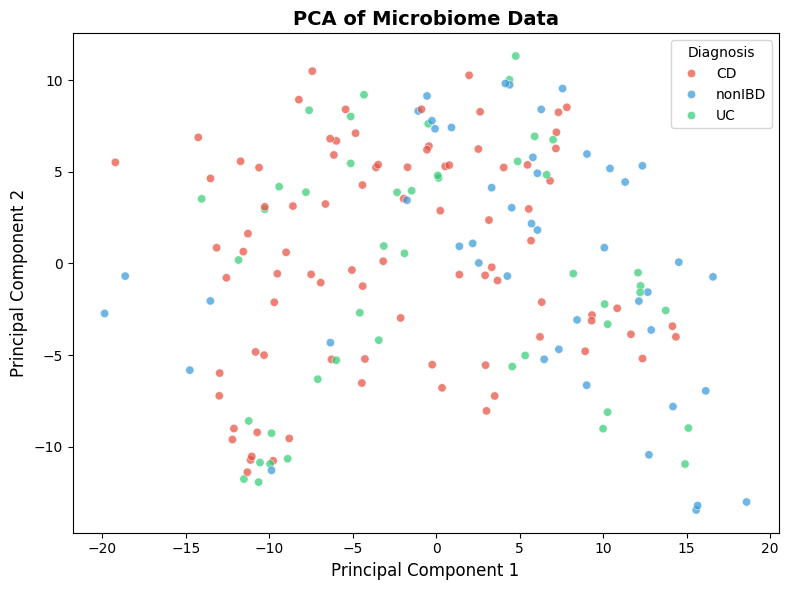

In [92]:
#apply PCA with n=50 components to reduce dimensionality while retaining most variance
from sklearn.decomposition import PCA
pca = PCA(n_components=50, random_state=42)
otu_pca = pca.fit_transform(otu_final)
print(f"PCA shape: {otu_pca.shape}")
print(f"Explained variance by 50 components: {pca.explained_variance_ratio_.sum():.2%}")
pca_df = pd.DataFrame(otu_pca, columns=[f'PC{i+1}' for i in range(otu_pca.shape[1])], index=otu_final.index)
pca_df = pca_df.join(otu_meta[['diagnosis']])
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='diagnosis', palette=['#e74c3c','#3498db','#2ecc71'], alpha=0.7)
plt.title('PCA of Microbiome Data', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.legend(title='Diagnosis')
plt.tight_layout()
plt.savefig('../figures/pca_scatter.png', dpi=150)
print("PCA scatter plot saved to figures/pca_scatter.png")
plt.show()


In [95]:
#Run UMAP for dimensionality reduction between just nonIBD and IBD samples and visualization using n_neighbors=30 to capture local structure while maintaining global relationships.

umap_reducer = umap.UMAP(n_neighbors=30, random_state=42)
umap_embedding = umap_reducer.fit_transform(otu_final)
umap_df = pd.DataFrame(umap_embedding, columns=['UMAP1', 'UMAP2'], index=otu_final.index)
umap_df = umap_df.join(otu_pca[['diagnosis']])
plt.figure(figsize=(8, 6))
sns.scatterplot(data=umap_df, x='UMAP1', y='UMAP2', hue='diagnosis', palette=['#e74c3c','#3498db','#2ecc71'], alpha=0.7)
plt.title('UMAP of Microbiome Data', fontsize=14, fontweight='bold')
plt.xlabel('UMAP Dimension 1', fontsize=12)
plt.ylabel('UMAP Dimension 2', fontsize=12)
plt.legend(title='Diagnosis')
plt.tight_layout()
plt.savefig('../figures/umap_scatter.png', dpi=150)
print("UMAP scatter plot saved to figures/umap_scatter.png")

/Users/liamcampbell/Desktop/crohns-microbiome-ml/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

Alpha diversity computed — Shannon diversity calculated per sample, boxplot (CD vs nonIBD) saved, Mann-Whitney p-value reported, biological finding noted (do Crohn's patients have lower diversity?)

Microbiome Metrics - quantitative tools that summarize microbial  composition and structure. 

**Alpha Diversity** - diversity within a single sample.

**Beta Diversity** - diversity between samples.

Together, they describe both the internal complexity of each microbiome and how communities differ across environments, hosts, or treatments.

**Alpha Diversity**

Reflects diversity within single microbial community. It combines:

*Richness* - the number of taxa detected (species, OTUs, or ASVs)
*Evenness* - how evenly those taxa are distributed in abundance.

**High Alpha Diversity** - can indicate ecological stability, resilience, or environmental heterogeneity.

**Low Alpha Diversity** - may signal disturbance, infection, or dominance by a few resilient species. 

**Alpha Diversity Metrics**

1. *Observed Taxa (Richness)* 
    - Counts unique species or ASVs.
    - Simple but ignores evenness
2. *Chao1 Index*
    - Estimates true richness by accounting for rare taxa. 
3. *Shannon Index*
    - Combines richness and evenness
    - Increases as community becomes more balanced
    - Sensitive to moderately abundant species
4. *Simpson Index*
    - Emphasizes dominance by abundant species
    - Often presented as 1 - D (Simpson diversity)
5. *Faith's Phylogenetic Diversity (PD)
    - Considers evolutionary distances among taxa
    - Sums branch lengths in a phylogenetic tree covering observed species
    - Useful when taxonomy is uncertain


Specific Project Info : 
    In human gut microbiome studies, reduced Shannon Diversity is often linked to inflammatory bowel disease (IBD). A lower diversity suggests loss of beneficial taxa and expansion of inflammation-tolerant microbes.


In [87]:
from scipy.stats import mannwhitneyu

# --- Shannon Diversity per Sample ---
# Shannon index: H = -sum(p_i * log(p_i))
# where p_i is the relative proportion of each taxon in a sample.

def shannon_diversity(row):
    """Compute Shannon entropy (H) for a single sample (row of counts)."""
    counts = row[row > 0]            # drop zeros
    if counts.sum() == 0:
        return 0.0
    proportions = counts / counts.sum()
    return -(proportions * np.log(proportions)).sum()

# Apply to every sample (row) in the raw OTU table
shannon = otu_only.apply(shannon_diversity, axis=1)
shannon.name = 'shannon_H'

# Attach diagnosis labels
shannon_df = shannon.to_frame().join(otu_meta['diagnosis'])

print("Shannon diversity computed for", len(shannon_df), "samples")
print()
print(shannon_df.groupby('diagnosis')['shannon_H'].describe().round(3))

TypeError: loop of ufunc does not support argument 0 of type float which has no callable log method

/var/folders/9z/qzwb0qz50ml05y5ptvkxby3r0000gn/T/ipykernel_23045/3854200491.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=order, patch_artist=True, widths=0.5,


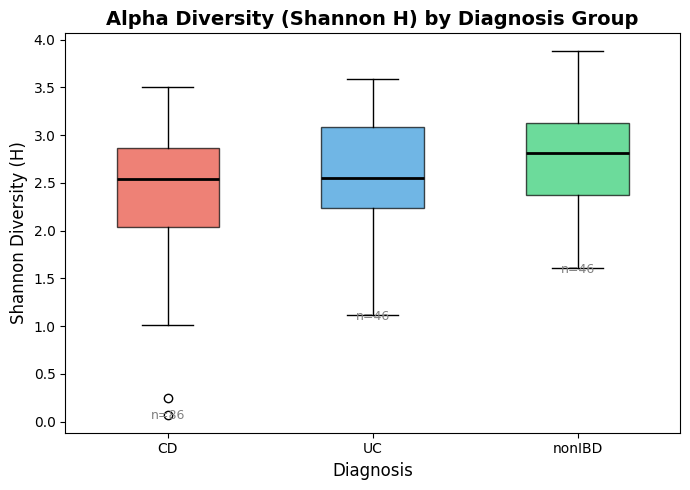

Boxplot saved to figures/shannon_diversity_boxplot.png


In [ ]:
# --- Boxplot: Shannon Diversity by Diagnosis Group ---

fig, ax = plt.subplots(figsize=(7, 5))

order = ['CD', 'UC', 'nonIBD']
colors = {'CD': '#e74c3c', 'UC': '#3498db', 'nonIBD': '#2ecc71'}

groups = [shannon_df[shannon_df['diagnosis'] == d]['shannon_H'] for d in order]

bp = ax.boxplot(groups, labels=order, patch_artist=True, widths=0.5,
                medianprops=dict(color='black', linewidth=2))

for patch, d in zip(bp['boxes'], order):
    patch.set_facecolor(colors[d])
    patch.set_alpha(0.7)

ax.set_title('Alpha Diversity (Shannon H) by Diagnosis Group', fontsize=14, fontweight='bold')
ax.set_xlabel('Diagnosis', fontsize=12)
ax.set_ylabel('Shannon Diversity (H)', fontsize=12)

# Annotate with sample sizes
for i, (d, grp) in enumerate(zip(order, groups), start=1):
    ax.text(i, grp.min() - 0.05, f'n={len(grp)}', ha='center', fontsize=9, color='grey')

plt.tight_layout()
plt.savefig('../figures/shannon_diversity_boxplot.png', dpi=150)
plt.show()
print("Boxplot saved to figures/shannon_diversity_boxplot.png")

In [ ]:
# --- Mann-Whitney U Test: CD vs nonIBD ---
# Non-parametric test — no normality assumption needed (good for microbiome data).

cd_vals = shannon_df[shannon_df['diagnosis'] == 'CD']['shannon_H']
nonibd_vals = shannon_df[shannon_df['diagnosis'] == 'nonIBD']['shannon_H']

stat, p_value = mannwhitneyu(cd_vals, nonibd_vals, alternative='two-sided')

print(f"Mann-Whitney U Test — CD vs nonIBD")
print(f"  U statistic : {stat:.1f}")
print(f"  p-value     : {p_value:.4f}")
print()
if p_value < 0.05:
    cd_med = cd_vals.median()
    nonibd_med = nonibd_vals.median()
    direction = "lower" if cd_med < nonibd_med else "higher"
    print(f"  ✓ Significant (p < 0.05)")
    print(f"  CD median H = {cd_med:.3f}  |  nonIBD median H = {nonibd_med:.3f}")
    print(f"  → Crohn's patients show {direction} alpha diversity than healthy controls.")
else:
    print(f"  ✗ Not significant (p ≥ 0.05) — no strong diversity difference detected.")

Mann-Whitney U Test — CD vs nonIBD
  U statistic : 1414.0
  p-value     : 0.0071

  ✓ Significant (p < 0.05)
  CD median H = 2.544  |  nonIBD median H = 2.810
  → Crohn's patients show lower alpha diversity than healthy controls.


Next, we will calculate the **Beta Diversity** using the **Bray-Curtis Distance Matrix**. 

**Beta Diversity** will show us how similar two samples are to each other. This will help us understand whether Crohn's patients have a consistently different microbial community composition from healthy controls. 

We use **Bray-Curtis** method because it is a standard for microbiome work. It compares two samples based on the abundance of shared species, ranging from 0 (identical) to 1 (nothing in common). 

In [ ]:
bray_curtis_distances = skbio.diversity.beta_diversity("braycurtis", otu_only.values, ids=otu_only.index.tolist())
bray_curtis_dataframe = bray_curtis_distances.to_data_frame()
bray_curtis_dataframe.to_csv('../data/bray_curtis_distances.csv')
print("Bray-Curtis distance matrix saved to data/bray_curtis_distances.csv")

Bray-Curtis distance matrix saved to data/bray_curtis_distances.csv


In [ ]:
bray_curtis_distances_scipy = scipy.spatial.distance.cdist(otu_only.values, otu_only.values, metric='braycurtis')
bray_curtis_dataframe_scipy = pd.DataFrame(bray_curtis_distances_scipy, index=otu_only.index, columns=otu_only.index)
bray_curtis_dataframe_scipy.to_csv('../data/bray_curtis_distances_scipy.csv')
print("Bray-Curtis distance matrix saved to data/bray_curtis_distances_scipy.csv")

Bray-Curtis distance matrix saved to data/bray_curtis_distances_scipy.csv


Now we will use **UMAP** (Uniform Manifold Approximation and Projection) to reduce the matrices dimensions. 

UMAP will take our high-dimensional data and project it onto a low-dimensional space (2D or 3D) for visualization or downstream machine learning. 

In [ ]:
reducer = umap.UMAP()
umap_embedding = reducer.fit_transform(otu_clr.values)
umap_df = pd.DataFrame(umap_embedding, columns=['UMAP1', 'UMAP2'], index=otu_clr.index)
umap_df = umap_df.join(otu_meta['diagnosis'])           
print("UMAP embedding created with shape:", umap_df.shape)

UMAP embedding created with shape: (178, 3)


UMAP plot saved to figures/umap_projection.png


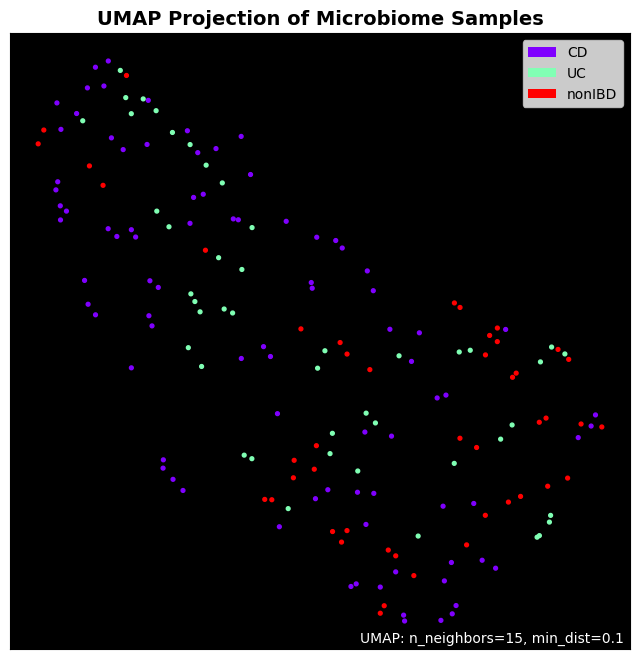

In [ ]:
#UMAP Visualization - 2D plot colored by diagnosis group. Should show separation between CD adn nonIBD if there are strong compositional differences.
umap.plot.points(reducer, labels=otu_meta['diagnosis'], theme='fire')
plt.title('UMAP Projection of Microbiome Samples', fontsize=14, fontweight='bold')
plt.savefig('../figures/umap_projection.png', dpi=150)
print("UMAP plot saved to figures/umap_projection.png")
plt.show()